# Quickstart

This quickstart builds a tiny system with a linear source feeding an integrator. You will connect the components, run a simulation, and plot the results.


## Import SysSimX

We use the `CoSimComponent`, `System`, and `Connection` classes, plus `matplotlib` for plotting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from syssimx import CoSimComponent, Connection, System, SystemGraphVisualizer
from syssimx.core import PortSpec, PortType

## Define the Components

We define a linear source `y = a * t + b` and a simple integrator that accumulates its input over time.


In [2]:
class LinearSource(CoSimComponent):
    """Linear source: y(t) = a * t + b."""

    def __init__(self, name: str, a: float = 1.0, b: float = 0.0):
        super().__init__(name, group="Source")
        self.a = a
        self.b = b
        self.output_specs.update({
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names=None):
        self.outputs["y"].set(self.a * t + self.b, t)


class Integrator(CoSimComponent):
    """Integrator with explicit Euler stepping."""

    def __init__(self, name: str, x0: float = 0.0):
        super().__init__(name, group="Integrator")
        self.x0 = x0
        self.input_specs.update({
            "u": PortSpec(name="u", type=PortType.REAL, direction="in")
        })
        self.output_specs.update({
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        u = self.inputs["u"].get()
        self.x += u * dt

    def _update_output_states(self, t: float | None = None, event_names=None):
        self.outputs["y"].set(self.x, t)


## Build the System

We connect the source output to the integrator input and initialize the system.


In [3]:
source = LinearSource(name="LinearSource", a=1.0, b=0.0)
integrator = Integrator(name="Integrator", x0=0.0)

system = System(name="QuickstartSystem")
system.add_component(source)
system.add_component(integrator)

system.add_connection(Connection(
    src_comp=source.name,
    src_port=source.output_specs["y"].name,
    dst_comp=integrator.name,
    dst_port=integrator.input_specs["u"].name,
))

system.initialize(t0=0.0)


## Inspect the System

`system.describe()` prints a structural report of the assembled system: components, connections, the computed execution order, detected algebraic loops, and the selected master algorithm. Since the system is already initialized, the execution order is included.

In [ ]:
print(system.describe())

## Visualize the System Graph

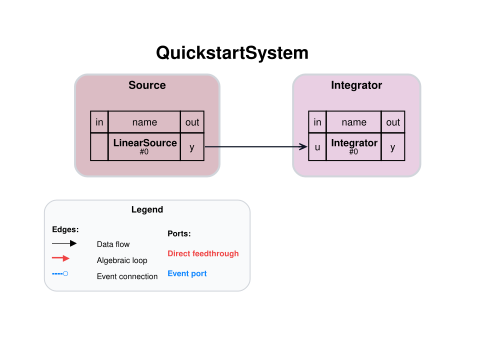

In [4]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("first_system_graph.svg")

## Run the Simulation

We simulate for 5 seconds with a fixed step size. `system.run()` returns a `SimulationResult` that bundles the recorded component histories with run metadata (time span, macro step, wall time, algorithm).


In [6]:
t0 = 0.0
tf = 5.0
dt = 0.1

result = system.run(t0=t0, tf=tf, dt=dt)


## Work With the Result

The returned `SimulationResult` is the recommended way to access simulation outputs:

- `result["Integrator"]` returns `(time_array, {port: values})` for one component.
- `result.to_dataframe()` returns a tidy long-format pandas DataFrame (`component`, `port`, `time`, `value`); `result.to_dataframe(component="Integrator")` returns a wide DataFrame with one column per output port.
- `result.to_csv("run.csv")` exports the same data to CSV.
- `result.events` holds the recorded event log, and `result.wall_time`, `result.algorithm`, `result.dt` expose the run metadata.

In [ ]:
result

In [ ]:
result.to_dataframe(component="Integrator").head()

## Visualize Results

The integrator output is the integral of the linear source. For `a=1` and `b=0`, the expected shape is quadratic.


In [10]:
y_analytical = lambda t: 0.5 * t**2
dt_an = 1e-4
t_vals_an = np.arange(t0, tf + dt_an, dt_an)
y_analytical_vals = y_analytical(t_vals_an)

In [ ]:
t_vals, data = result["Integrator"]
y_vals = data["y"]

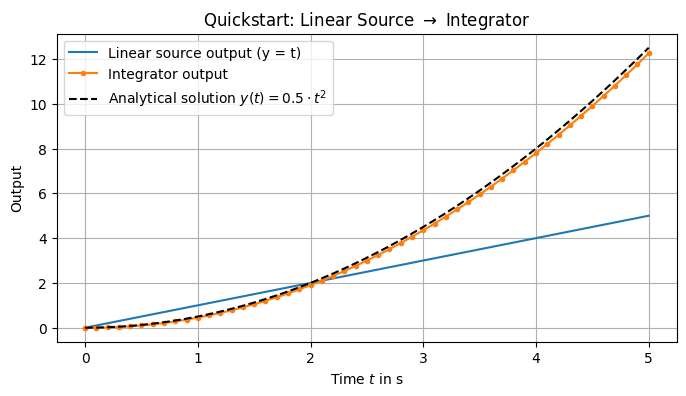

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(t_vals, t_vals, label="Linear source output (y = t)")
plt.plot(t_vals, y_vals, label="Integrator output", marker=".")
plt.plot(t_vals_an, y_analytical_vals, label=r"Analytical solution $y(t) = 0.5 \cdot t^2$", color="black", linestyle="--")
plt.xlabel(r"Time $t$ in s")
plt.ylabel("Output")
plt.title("Quickstart: Linear Source $\\to$ Integrator")
plt.grid()
plt.legend()
plt.show()

## Next Steps

- Explore more example systems in the {doc}`/03_core_tutorials/01_fundamentals/index` chapter.
- See {doc}`/03_core_tutorials/01_fundamentals/03_first_system` for a slightly larger system with feedback.
- See {doc}`/03_core_tutorials/01_fundamentals/02_importing_fmus` for loading FMU components.
- Systems can also be defined declaratively in YAML/JSON and run from the command line — see {doc}`/03_core_tutorials/02_intermediate/04_declarative_systems`.